# Player & Pick Trends

Exploratory analysis on the value data (KTC + FantasyCalc) and rookie-draft outcomes:
1. Player value by position over time
2. Draft capital -> long-term value (rookie pick slot vs the drafted player's value +1/+2/+3 yrs later)
3. Pick EV (what a rookie pick *returns* in realized player value)
4. Ad-hoc: value vs career stage, value concentration

In [1]:
import sys; sys.path.insert(0, ".")
import fantasy_lib as F
import polars as pl
import matplotlib.pyplot as plt
from datetime import date
pl.Config.set_tbl_rows(20)
CACHE = F.CACHE
SKILL = ["QB","RB","WR","TE"]

pv = F.load_player_values()                          # valuation_date, player_id, name, position, ktc_value, fc_value
fr, pm = F.load_dims()
print(f"player values: {pv.height:,} rows  {pv['valuation_date'].min()} -> {pv['valuation_date'].max()}")

player values: 562,568 rows  2020-04-01 -> 2026-06-13


## 1. Player value by position over time (median KTC, skill positions)

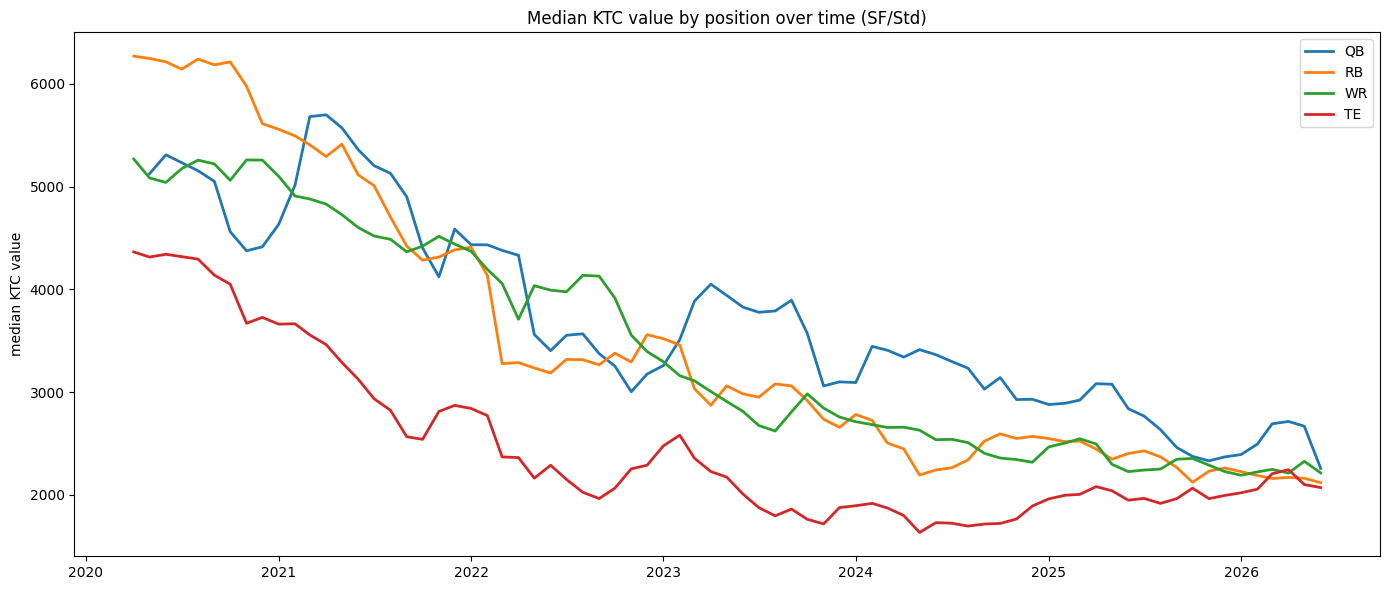

In [2]:
monthly = (pv.filter(pl.col("position").is_in(SKILL) & (pl.col("ktc_value")>0))
           .with_columns(pl.col("valuation_date").dt.truncate("1mo").alias("month"))
           .group_by("position","month").agg(pl.col("ktc_value").median().alias("med")))
fig, ax = plt.subplots(figsize=(14,6))
for pos in SKILL:
    s = monthly.filter(pl.col("position")==pos).sort("month")
    ax.plot([d for d in s["month"]], s["med"].to_list(), label=pos, linewidth=2)
ax.set_title("Median KTC value by position over time (SF/Std)"); ax.set_ylabel("median KTC value")
ax.legend(); fig.tight_layout(); fig.savefig(CACHE/"pos_value_time.png", dpi=90); plt.show()

## 2. Draft capital -> long-term value
For each rookie-draft pick, the drafted player's KTC value 1 / 2 / 3 years later (June 1).

In [3]:
rookies = F.load_rookie_draft_picks().filter(~pl.col("is_startup") & pl.col("player_id").is_not_null())
print("rookie picks:", rookies.height, "| seasons:", sorted(rookies['season'].unique().to_list()))

pvx = pv.select("valuation_date","player_id","ktc_value").drop_nulls().sort("valuation_date")
frames = []
for h in (1,2,3):
    tgt = rookies.with_columns((pl.col("season")+h).alias("yr")).with_columns(
        (pl.col("yr").cast(pl.Utf8)+"-06-01").str.to_date().alias("as_of")).sort("as_of")
    j = tgt.join_asof(pvx, left_on="as_of", right_on="valuation_date", by="player_id", strategy="backward")
    frames.append(j.with_columns(pl.lit(h).alias("horizon"), pl.col("ktc_value").fill_null(0).alias("value")))
capital = pl.concat([f.select("season","round","draft_slot","pick_no","player_id","horizon","value") for f in frames])
capital.group_by("round","horizon").agg(pl.col("value").mean().round(0).alias("mean_value"),
                                        pl.len().alias("n")).sort("round","horizon")

rookie picks: 192 | seasons: [2022, 2023, 2024, 2025]


C:\Users\simer\AppData\Local\Temp\ipykernel_8140\1729052.py:9: UserWarning: Sortedness of columns cannot be checked when 'by' groups provided
  j = tgt.join_asof(pvx, left_on="as_of", right_on="valuation_date", by="player_id", strategy="backward")


round,horizon,mean_value,n
i64,i32,f64,u32
1,1,5644.0,64
1,2,5348.0,64
1,3,5365.0,64
2,1,3410.0,64
2,2,3255.0,64
2,3,3201.0,64
3,1,2292.0,64
3,2,2229.0,64
3,3,2214.0,64


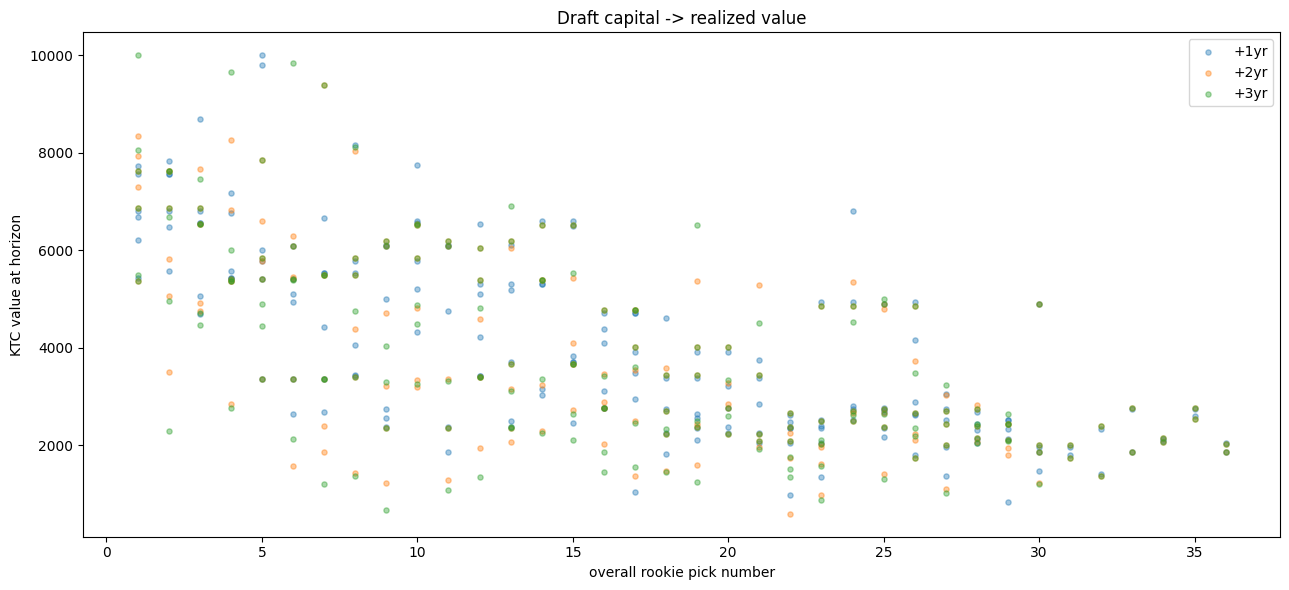

In [4]:
# scatter: overall pick number vs value at +2yr (the long-term payoff curve)
fig, ax = plt.subplots(figsize=(13,6))
for h in (1,2,3):
    s = capital.filter((pl.col("horizon")==h) & (pl.col("value")>0))
    ax.scatter(s["pick_no"].to_list(), s["value"].to_list(), s=14, alpha=0.4, label=f"+{h}yr")
ax.set_xlabel("overall rookie pick number"); ax.set_ylabel("KTC value at horizon")
ax.set_title("Draft capital -> realized value"); ax.legend(); fig.tight_layout()
fig.savefig(CACHE/"draft_capital.png", dpi=90); plt.show()

## 3. Pick EV
Average realized value by **round** at each horizon = an empirical expected value for a rookie pick,
to compare against what the market (`fact_pick_values`) prices the pick at.

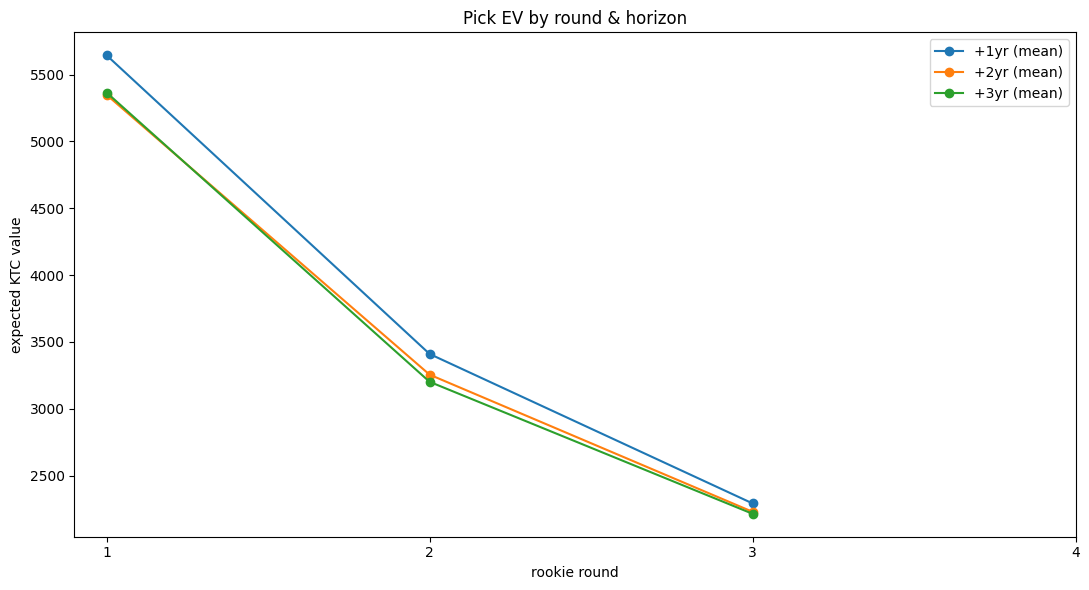

round,horizon,ev,med
i64,i32,f64,f64
1,1,5644.296875,5569.5
1,2,5348.375,5497.0
1,3,5365.296875,5416.0
2,1,3409.78125,3295.5
2,2,3254.984375,3189.5
2,3,3201.453125,2757.0
3,1,2291.65625,2343.5
3,2,2228.9375,2133.5
3,3,2214.171875,2150.0


In [5]:
ev = capital.group_by("round","horizon").agg(pl.col("value").mean().alias("ev"),
                                            pl.col("value").median().alias("med")).sort("round","horizon")
fig, ax = plt.subplots(figsize=(11,6))
for h in (1,2,3):
    s = ev.filter(pl.col("horizon")==h).sort("round")
    ax.plot(s["round"].to_list(), s["ev"].to_list(), marker="o", label=f"+{h}yr (mean)")
ax.set_xlabel("rookie round"); ax.set_ylabel("expected KTC value"); ax.set_xticks([1,2,3,4])
ax.set_title("Pick EV by round & horizon"); ax.legend(); fig.tight_layout()
fig.savefig(CACHE/"pick_ev.png", dpi=90); plt.show()
ev

## 4. Ad-hoc: value vs career stage (years since NFL draft)

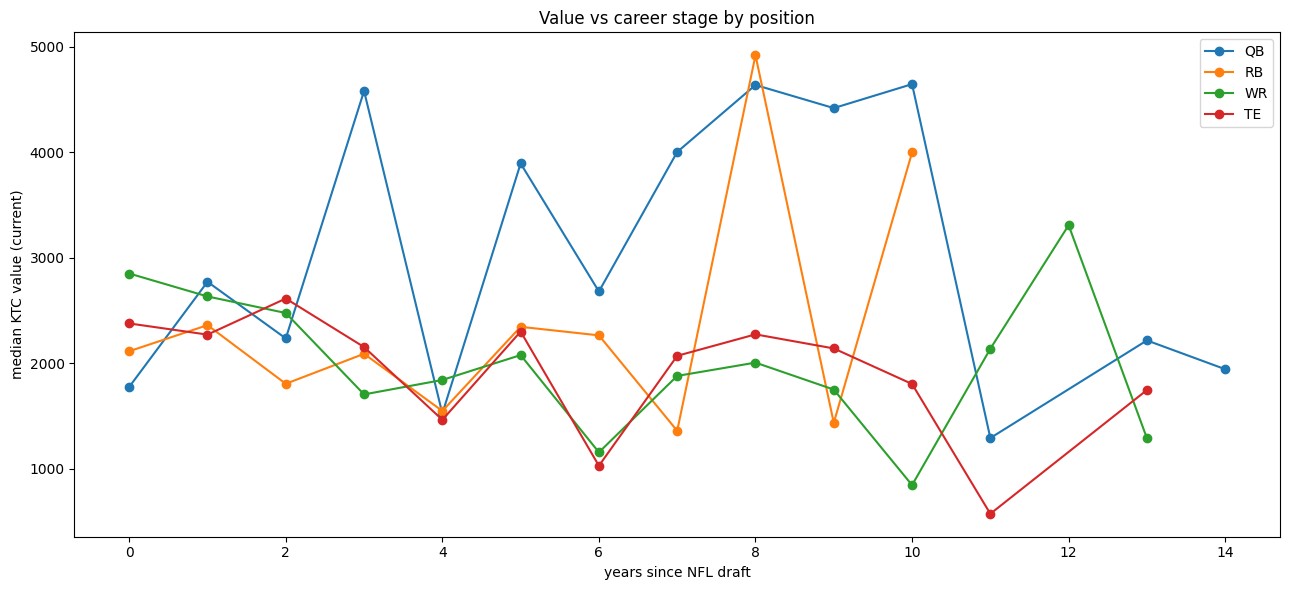

In [6]:
dim = pm.select(pl.col("player_key").alias("player_id"), "position", "draft_year")
latest = pv["valuation_date"].max()
career = (pv.filter((pl.col("valuation_date")==latest) & pl.col("position").is_in(SKILL) & (pl.col("ktc_value")>0))
          .join(dim, on="player_id", how="left").drop_nulls("draft_year")
          .with_columns((latest.year - pl.col("draft_year")).alias("yrs_in_league"))
          .filter((pl.col("yrs_in_league")>=0) & (pl.col("yrs_in_league")<=15)))
curve = career.group_by("position","yrs_in_league").agg(pl.col("ktc_value").median().alias("med"))
fig, ax = plt.subplots(figsize=(13,6))
for pos in SKILL:
    s = curve.filter(pl.col("position")==pos).sort("yrs_in_league")
    ax.plot(s["yrs_in_league"].to_list(), s["med"].to_list(), marker="o", label=pos)
ax.set_xlabel("years since NFL draft"); ax.set_ylabel("median KTC value (current)")
ax.set_title("Value vs career stage by position"); ax.legend(); fig.tight_layout()
fig.savefig(CACHE/"aging_curve.png", dpi=90); plt.show()